In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [6]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_shot,
    calc_S_RIN,
    calc_S_ADC,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam,
    calculate_ps2
)

In [ ]:
from scipy.fft import fft, ifft, fftfreq
import scipy.special as sp
import time
import scipy.constants as const

# FUNÇÕES AUXILIARES (Q-Factor e BER PAM-M)
def qfunc(x):
    return 0.5 * sp.erfc(x / np.sqrt(2))

def ber_from_snr_m_pam(snr_lin, M):
    return (2 * (M - 1) / (M * np.log2(M))) * qfunc(np.sqrt((3 * snr_lin) / (M**2 - 1)))


Iniciando Varredura. Aguarde...

DIAGNÓSTICO DO SINAL ÓPTICO (SIMULAÇÃO vs TEORIA)
OMA Teórico:   1.7626e-03 W
OMA Simulado:  1.7626e-03 W
ER Teórico:    12.00 dB
ER Simulado:   12.00 dB

>> Processando RIN = -150 dB/Hz

----------------------------------------
DIAGNÓSTICO DAS VARIÂNCIAS DE RUÍDO (DOMÍNIO DO TEMPO)
Variância RIN Média:  8.0059e-11 A^2
Variância Térmica:    1.1200e-08 A^2
Variância Shot Média: 1.7942e-11 A^2
----------------------------------------

>> Processando RIN = -145 dB/Hz
>> Processando RIN = -140 dB/Hz
>> Processando RIN = -135 dB/Hz
>> Processando RIN = -130 dB/Hz
>> Processando RIN = -125 dB/Hz
>> Processando RIN = -120 dB/Hz

Tempo Total: 0.99 min


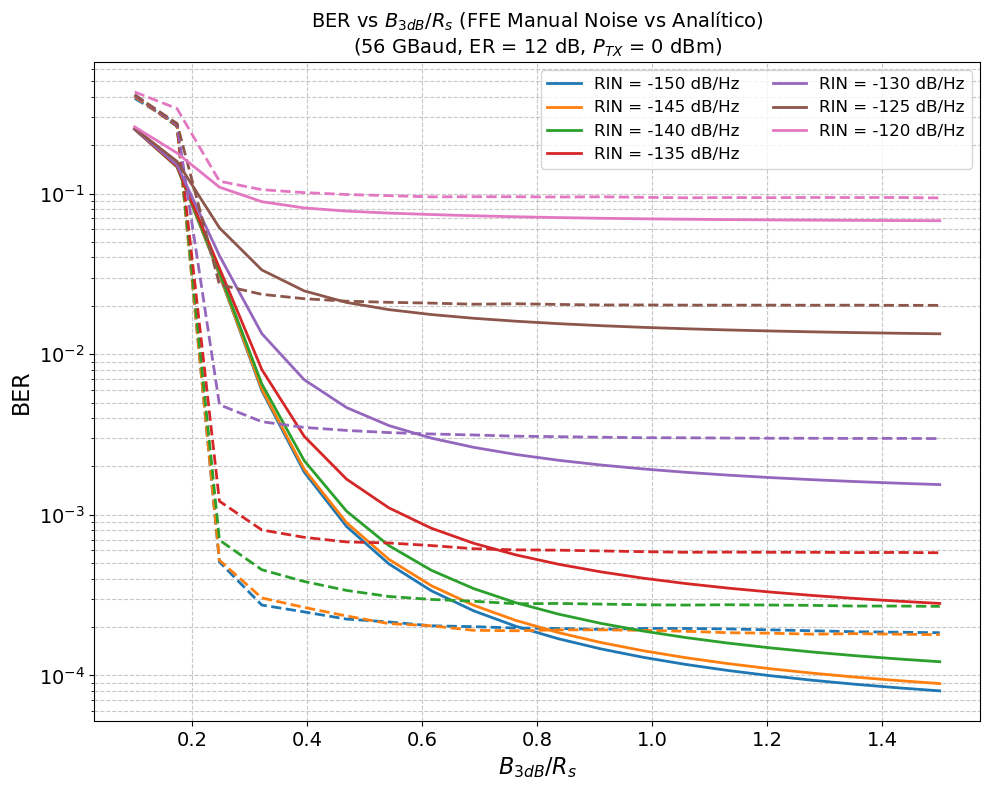

In [8]:
# PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
Rs = 56e9            # Artigo: 56 GBaud
P_avg_alvo = 1.0     # Artigo: PTX = 0 dBm (1 mW)
pTx_W = P_avg_alvo * 1e-3
M = 4                # Artigo: 4-PAM
er_db = 12.0         # Artigo: ER = 12 dB

N0 = 2e-19
c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c
kB = const.value("Boltzmann constant")
T_kelvin = 70 + 273.15
q_e = const.e  # Carga do elétron

DAC_ADC = False

SpS_TX = 2
Fs = Rs * SpS_TX
n_dac = 5 if DAC_ADC else 1
Res = 8
sim_Fs = n_dac * Fs
TX_Ts = 1 / Rs

n_order = 1 
SIM_N = 10000

# Eixos da Varredura
bw_ratios = np.linspace(0.1, 1.5, 20)
# Artigo: range de -150 dB/Hz até -120 dB/Hz
rin_values = [-150, -145, -140, -135, -130, -125, -120] 

# Estruturas para armazenar os resultados
ber_ana_results = {rin: [] for rin in rin_values}
ber_sim_results = {rin: [] for rin in rin_values}

# Eixos de frequência para o modelo analítico
SIM_fmax = 3e12
f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
Tb = 1 / (Rs * 2)
Pulse_f = np.sinc(2 * Tb * f_analytical)

print("Iniciando Varredura. Aguarde...")
start_time = time.time()

# GERAÇÃO DO TRANSMISSOR IDEAL
paramBits = parameters()
paramBits.nBits = 1000000  
paramBits.mode = 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

symb_Tx = modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS_TX)

paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS_TX
pulse = pulseShape(paramPulse)

signal_Tx_base = firFilter(pulse, symb_Tx_up)

# Cálculos Base Analíticos
ER_lin = 10**(er_db/10)
x = (ER_lin - 1) / (ER_lin + 1)

OMA_outer = calculate_oma_outer(pTx_W, er_db)
Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
S_th_array = calc_S_th(N0, f_analytical)
S_shot_array = calc_S_shot(pTx_W, 1.0, 1, 1, f_analytical)

# Normalização estrita do sinal [-1, 1]
signal_Tx_norm_base = signal_Tx_base / np.max(np.abs(signal_Tx_base))

if DAC_ADC:
    paramDAC = parameters()
    paramDAC.inFs = Fs            
    paramDAC.outFs = sim_Fs       
    paramDAC.nBits = Res         
    paramDAC.ENOB = paramDAC.nBits          
    paramDAC.Vpp = 2.0         
    paramDAC.AIF = True  
    signal_Tx_norm = dac(signal_Tx_norm_base, paramDAC)
else:
    signal_Tx_norm = signal_Tx_norm_base

f_sim = fftfreq(len(signal_Tx_norm), d=1/sim_Fs)

# VERIFICAÇÃO DE OMA E ER 
P_opt_ideal = pTx_W * (1 + x * signal_Tx_norm)
sim_OMA = np.max(P_opt_ideal) - np.min(P_opt_ideal)
sim_ER_dB = 10 * np.log10(np.max(P_opt_ideal) / np.min(P_opt_ideal))

print("\n" + "="*50)
print("DIAGNÓSTICO DO SINAL ÓPTICO (SIMULAÇÃO vs TEORIA)")
print(f"OMA Teórico:   {OMA_outer:.4e} W")
print(f"OMA Simulado:  {sim_OMA:.4e} W")
print(f"ER Teórico:    {er_db:.2f} dB")
print(f"ER Simulado:   {sim_ER_dB:.2f} dB")
print("="*50 + "\n")

# LOOP PRINCIPAL (RIN -> B_3dB)
for rin_idx, rin in enumerate(rin_values):
    print(f">> Processando RIN = {rin} dB/Hz")
    
    S_RIN_global = calc_S_RIN(Ps2, rin, f_analytical)
    rin_lin = 10**(rin / 10)
    
    # Adição do RIN
    var_n_rin = (rin_lin / 2) * sim_Fs
    n_rin = np.random.normal(0, np.sqrt(var_n_rin), len(P_opt_ideal))
    P_opt_com_rin = P_opt_ideal * np.maximum(1 + n_rin, 0.0)

    # RECEPTOR: FOTODIODO MANUAL (CONVERSÃO P -> I + RUÍDOS)
    R_pd = 1.0 
    I_pd = R_pd * P_opt_com_rin
    
    # 1. Ruído Térmico (PSD N0 unipolar -> Variância = N0 * sim_Fs / 2)
    var_th = N0 * (sim_Fs / 2)
    i_th = np.random.normal(0, np.sqrt(var_th), len(I_pd))
    
    # 2. Ruído de Disparo (Dependente do sinal instantâneo)
    # Variância = 2 * q * I * (sim_Fs / 2) = q * I * sim_Fs
    var_shot = q_e * I_pd * sim_Fs
    i_shot = np.random.normal(0, np.sqrt(var_shot))
    
    # Corrente RX Total
    PD_signalRx = I_pd + i_shot + i_th
    
    #  DIAGNÓSTICO DE RUÍDO (Printa apenas no primeiro RIN) 
    if rin_idx == 0:
        print("\n" + "-"*40)
        print("DIAGNÓSTICO DAS VARIÂNCIAS DE RUÍDO (DOMÍNIO DO TEMPO)")
        print(f"Variância RIN Média:  {np.mean((P_opt_ideal * n_rin)**2):.4e} A^2")
        print(f"Variância Térmica:    {var_th:.4e} A^2")
        print(f"Variância Shot Média: {np.mean(var_shot):.4e} A^2")
        print("-"*40 + "\n")

    for bw_ratio in bw_ratios:
        B_3dB = bw_ratio * Rs
        
        # MODELO ANALÍTICO
        H_ch_total_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_N_total = calc_S_N(S_RIN_global, S_shot_array, S_th_array, 0, H_ch_sq_ana, False)
        S_N_f = get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=2, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) 
        SNR_f_interp = 10**(np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR)) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        ber_ana_results[rin].append(ber_from_snr_m_pam(snr_ffe_lin, M))
        
        #  SIMULAÇÃO 
        H_ch_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        PD_signalRx_filtered = np.real(ifft(fft(PD_signalRx) * H_ch_sim))
        paramdec = parameters()
        paramdec.SpSin = SpS_TX
        paramdec.SpSout = 2
        
        if DAC_ADC:
            paramAdc = parameters()
            paramAdc.inFs = sim_Fs
            paramAdc.outFs = Fs
            paramAdc.nBits = paramDAC.nBits
            paramAdc.ENOB = paramDAC.ENOB
            paramAdc.Vmax = np.max(np.abs(PD_signalRx_filtered))
            paramAdc.Vmin = -paramAdc.Vmax
            paramAdc.AAF = False 
            
            sigRx = adc(PD_signalRx_filtered, paramAdc)
            sigRx = firFilter(pulse, sigRx) 
        else:
            sigRx = firFilter(pulse, PD_signalRx_filtered)
            sigRx = decimate(sigRx, paramdec) 
        
        nTrain = 100000
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 5e-4
        paramFFE.nTrain = nTrain
        paramFFE.SpS = 2
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        discard = nTrain
        ber_ffe_sim, _, _ = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        ber_sim_results[rin].append(ber_ffe_sim[0])

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")

#PLOTAGEM DO GRÁFICO
plt.figure(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, rin in enumerate(rin_values):
    c = colors[i % len(colors)]
    plt.semilogy(bw_ratios, ber_ana_results[rin], '-', color=c, linewidth=2, label=f'RIN = {rin} dB/Hz')
    plt.semilogy(bw_ratios, ber_sim_results[rin], '--', color=c, linewidth=2)

plt.xlabel(r'$B_{3dB}/R_s$', fontsize=16)
plt.ylabel('BER', fontsize=16)
#plt.ylim(1e-4, 0.5)
#plt.xlim(0.1, 1.5)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=12, loc='upper right', ncol=2)
plt.title('BER vs $B_{3dB}/R_s$ (FFE Manual Noise vs Analítico)\n(56 GBaud, ER = 12 dB, $P_{TX}$ = 0 dBm)', fontsize=14)
plt.tight_layout()
plt.show()